In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame=True)

In [3]:
df = data.frame
print(df.shape)
print(df.head())
print(df.dtypes)
print("\nПропуски:")
print(df.isnull().sum())


(20640, 9)
   MedInc  HouseAge  AveRooms  ...  Latitude  Longitude  MedHouseVal
0  8.3252      41.0  6.984127  ...     37.88    -122.23        4.526
1  8.3014      21.0  6.238137  ...     37.86    -122.22        3.585
2  7.2574      52.0  8.288136  ...     37.85    -122.24        3.521
3  5.6431      52.0  5.817352  ...     37.85    -122.25        3.413
4  3.8462      52.0  6.281853  ...     37.85    -122.25        3.422

[5 rows x 9 columns]
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Пропуски:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


### Разделим датасет на тестовую и тренировочную выборки, а также промасштабируем данные

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=22
)


Обучим сразу все три модели 

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

models = {
    'Linear Regression': LinearRegression(),
    'SVR':               SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'Decision Tree':     DecisionTreeRegressor(max_depth=7, random_state=22)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    results[name] = {'MAE': round(mae, 4), 'R²': round(r2, 4), 'MSE' : round(mse,4)}

df_results = pd.DataFrame(results).T
print(df_results)

                      MAE      R²     MSE
Linear Regression  0.5267  0.6094  0.5075
SVR                0.3900  0.7387  0.3396
Decision Tree      0.4586  0.6778  0.4186


Лучшей моделью оказался SVR с RBF-ядром (MAE=0.39, R²=0.74, MSE=0.34). Это объясняется тем, что зависимость стоимости жилья от признаков носит нелинейный характер

Линейная регрессия показала средний результат (R²=0.61). Она установила базовую линию и подтвердила, что линейная составляющая в данных существенна, однако недостаточна для точного предсказания

Дерево решений с max_depth=7 (R²=0.68) заняло промежуточное положение. По сравнению с глубиной 3 качество значительно улучшилось, однако дерево аппроксимирует непрерывные зависимости ступенчато, что уступает гладким границам SVR. Главное преимущество дерева — интерпретируемость: анализ важности признаков показал, что наибольший вклад в предсказание цены вносят медианный доход (MedInc) и географические координаты (Latitude, Longitude), что логично и соответствует предметной области.

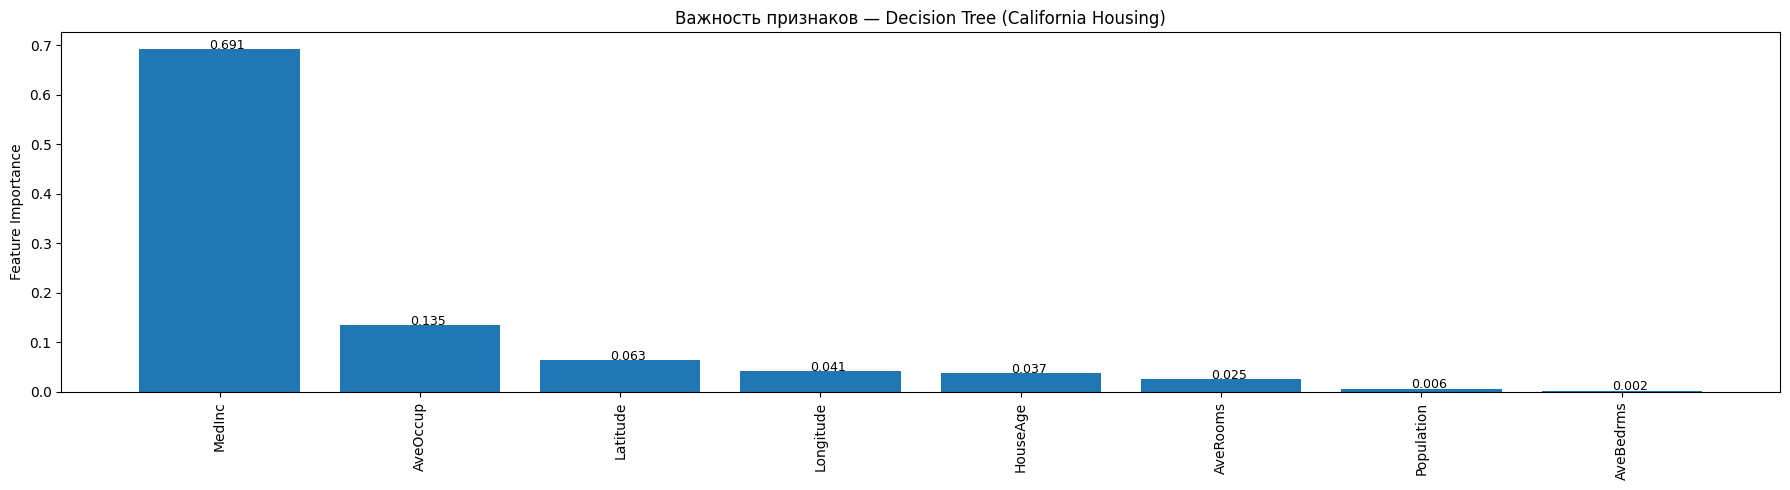

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from operator import itemgetter

def draw_feature_importances(tree_model, X_dataset, figsize=(18, 5)):
    
    list_to_sort = list(zip(X_dataset.columns.values, tree_model.feature_importances_))
    sorted_list = sorted(list_to_sort, key=itemgetter(1), reverse=True)

    labels = [x for x, _ in sorted_list]
    data   = [x for _, x in sorted_list]

    fig, ax = plt.subplots(figsize=figsize)
    ind = np.arange(len(labels))
    plt.bar(ind, data)
    plt.xticks(ind, labels, rotation='vertical')
    plt.title("Важность признаков — Decision Tree (California Housing)")
    plt.ylabel("Feature Importance")

    for a, b in zip(ind, data):
        plt.text(a - 0.05, b + 0.001, str(round(b, 3)), fontsize=9)

    plt.tight_layout()
    plt.show()
    return labels, data


labels, importances = draw_feature_importances(models['Decision Tree'], X)

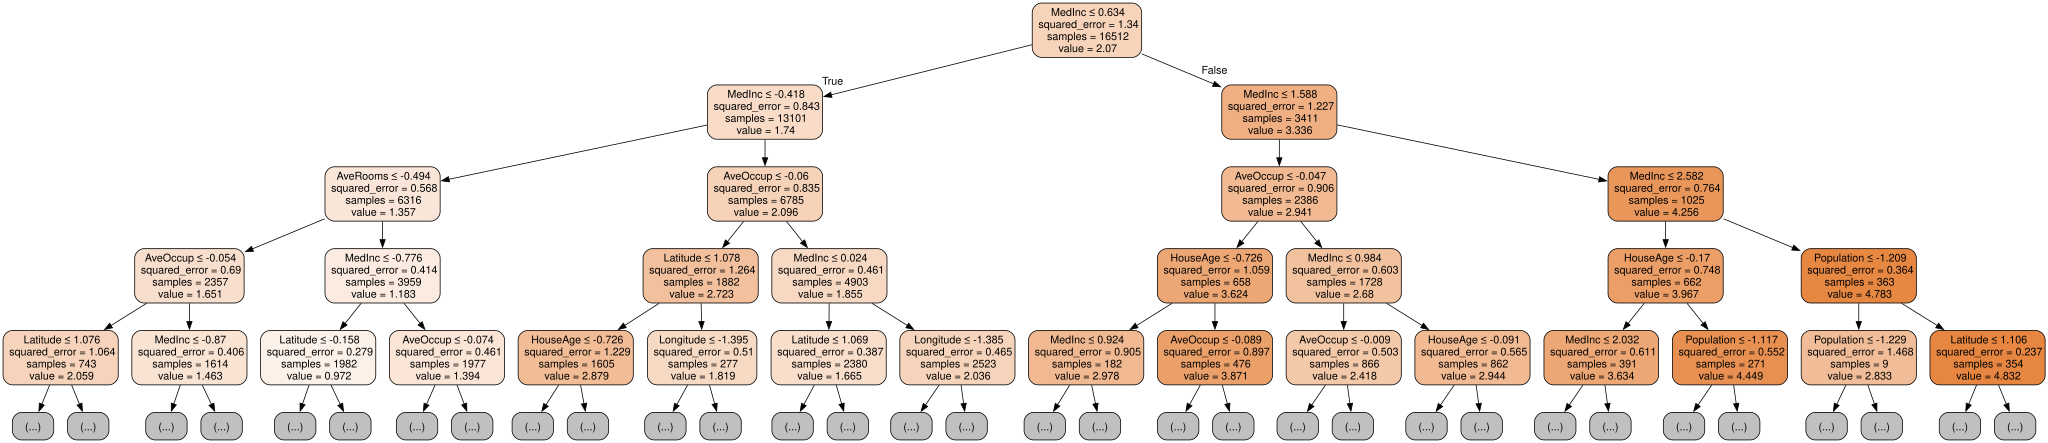

In [12]:
from sklearn.tree import export_graphviz
import graphviz

feature_names = list(X.columns)

dot_data = export_graphviz(
    models['Decision Tree'],
    out_file=None,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=4        
)

graph = graphviz.Source(dot_data)
graph.render('treee', format='png', cleanup=True)
graph  